In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

In [3]:
link = '/Users/maxkucher/preprocessing/mlops/bikes/data.csv'
data = pd.read_csv(link)
data

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129


In [4]:
data.isnull().sum()

datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64

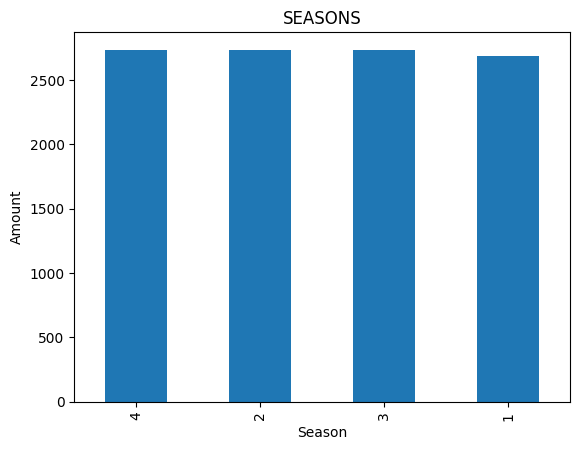

In [5]:
data['season'].value_counts().plot(kind='bar')

plt.title('SEASONS')
plt.ylabel('Amount')
plt.xlabel('Season')
plt.show()

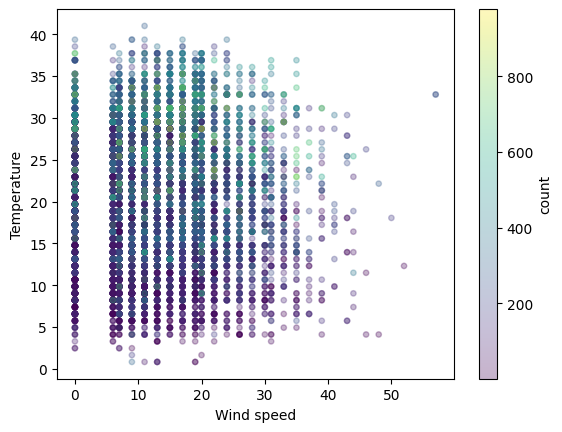

In [6]:
plt.scatter(data['windspeed'], data['temp'], c=data['count'], alpha=0.3, s=15)
plt.colorbar(label='count')

plt.xlabel('Wind speed')
plt.ylabel('Temperature')
plt.show()

<Axes: xlabel='hour'>

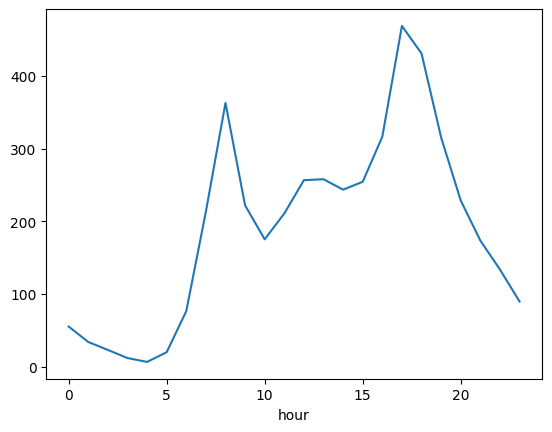

In [7]:
data['hour'] = pd.to_datetime(data['datetime']).dt.hour
data.groupby('hour')['count'].mean().plot()

<Axes: xlabel='hour'>

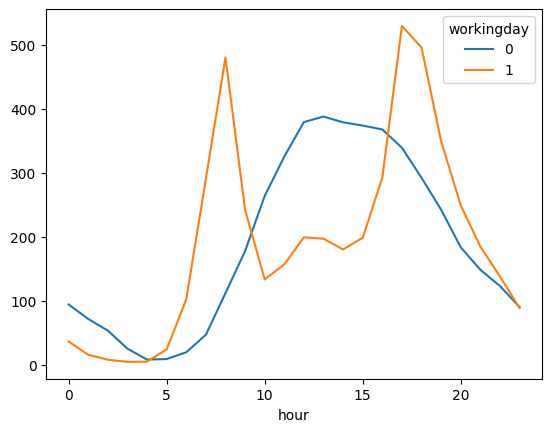

In [8]:
data.groupby(['hour', 'workingday'])['count'].mean().unstack().plot()


<Axes: xlabel='month'>

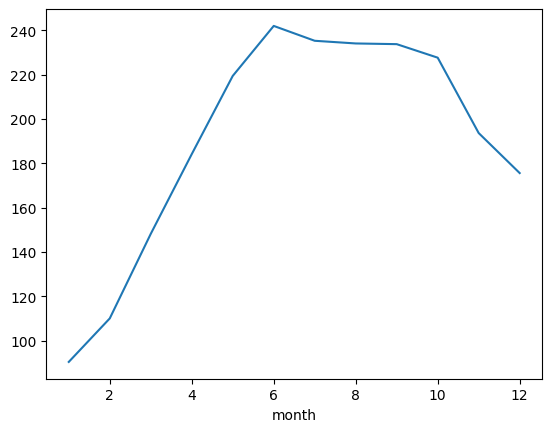

In [9]:
data['month'] = pd.to_datetime(data['datetime']).dt.month

data.groupby('month')['count'].mean().plot()

Text(0, 0.5, 'Count')

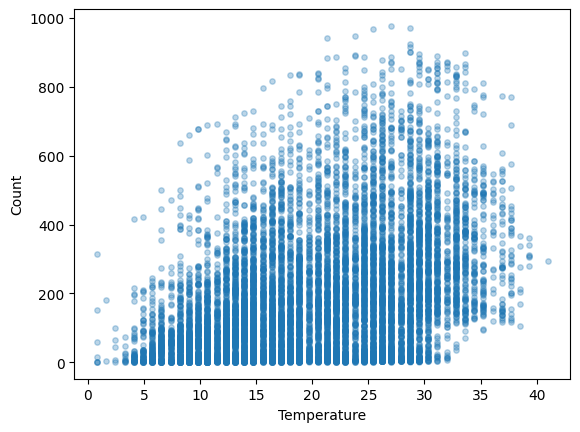

In [10]:
plt.scatter(data['temp'], data['count'], alpha=0.3, s=15)
plt.xlabel('Temperature')
plt.ylabel('Count')

<Axes: title={'center': 'count'}, xlabel='weather'>

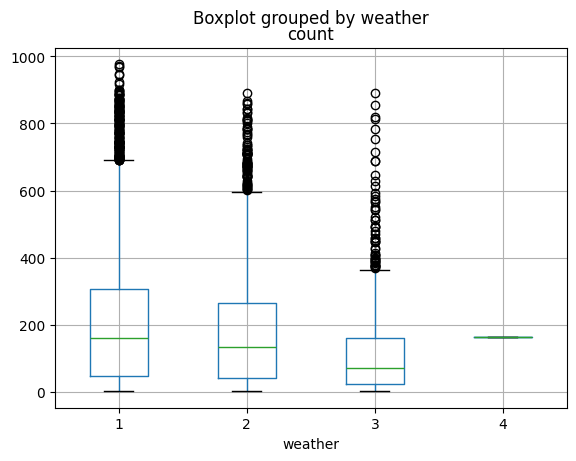

In [11]:
data.boxplot(column='count', by='weather')

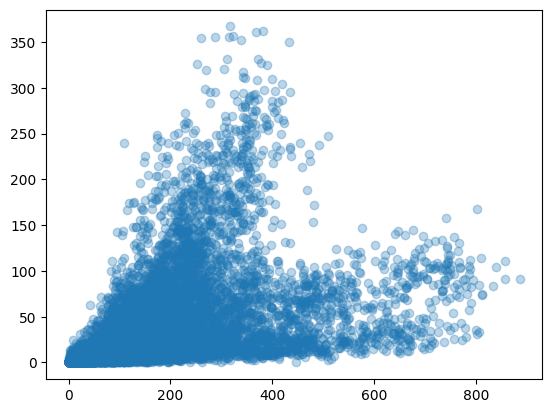

In [12]:
plt.scatter(data['registered'], data['casual'], alpha=0.3)


<Axes: >

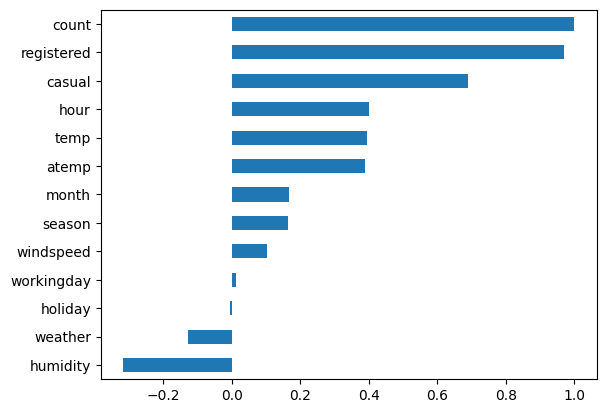

In [13]:
t_data = data.drop('datetime', axis='columns')

corr = t_data.corr()['count'].sort_values()
corr.plot(kind='barh')


In [14]:
data

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,hour,month
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16,0,1
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40,1,1
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32,2,1
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13,3,1
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10881,2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336,19,12
10882,2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241,20,12
10883,2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168,21,12
10884,2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129,22,12


In [15]:
columns_to_drop = ['datetime', 'casual', 'registered']
data = data.drop(columns_to_drop, axis='columns')
data

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,hour,month
0,1,0,0,1,9.84,14.395,81,0.0000,16,0,1
1,1,0,0,1,9.02,13.635,80,0.0000,40,1,1
2,1,0,0,1,9.02,13.635,80,0.0000,32,2,1
3,1,0,0,1,9.84,14.395,75,0.0000,13,3,1
4,1,0,0,1,9.84,14.395,75,0.0000,1,4,1
...,...,...,...,...,...,...,...,...,...,...,...
10881,4,0,1,1,15.58,19.695,50,26.0027,336,19,12
10882,4,0,1,1,14.76,17.425,57,15.0013,241,20,12
10883,4,0,1,1,13.94,15.910,61,15.0013,168,21,12
10884,4,0,1,1,13.94,17.425,61,6.0032,129,22,12


In [16]:
scaler = MinMaxScaler()
columns_to_scale = ['temp', 'atemp', 'humidity', 'windspeed']

for col in columns_to_scale:
    scaled = scaler.fit_transform(data[[col]])
    scaled_df = pd.DataFrame(scaled, columns=scaler.get_feature_names_out([col]), index=data.index)
    data = pd.concat([data.drop(col, axis='columns'), scaled_df], axis='columns')

data

,season,holiday,workingday,weather,count,hour,month,temp,atemp,humidity,windspeed
0,1,0,0,1,16,0,1,0.224490,0.305068,0.81,0.000000
1,1,0,0,1,40,1,1,0.204082,0.288064,0.80,0.000000
2,1,0,0,1,32,2,1,0.204082,0.288064,0.80,0.000000
3,1,0,0,1,13,3,1,0.224490,0.305068,0.75,0.000000
4,1,0,0,1,1,4,1,0.224490,0.305068,0.75,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
10881,4,0,1,1,336,19,12,0.367347,0.423649,0.50,0.456213
10882,4,0,1,1,241,20,12,0.346939,0.372860,0.57,0.263195
10883,4,0,1,1,168,21,12,0.326531,0.338964,0.61,0.263195
10884,4,0,1,1,129,22,12,0.326531,0.372860,0.61,0.105325
